In [1]:
import json
import statistics
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
data_path = Path("data/cuad/train_separate_questions.json")

if not data_path.exists():
    data_path = Path("../data/cuad/train_separate_questions.json")

with open(data_path, "r", encoding="utf-8") as file:
    dataset = json.load(file)

contracts = dataset["data"]

print("Dataset:", data_path)
print("Number of training contracts:", len(contracts))

Dataset: ..\data\cuad\train_separate_questions.json
Number of training contracts: 408


In [3]:
contract_lengths = []

for contract in contracts:
    text = ""

    for paragraph in contract["paragraphs"]:
        text += paragraph["context"]

    contract_lengths.append(len(text))

print("Minimum:", min(contract_lengths))
print("Maximum:", max(contract_lengths))
print("Mean:", statistics.mean(contract_lengths))
print("Median:", statistics.median(contract_lengths))

Minimum: 1081
Maximum: 338211
Mean: 53991.71078431373
Median: 35960.5


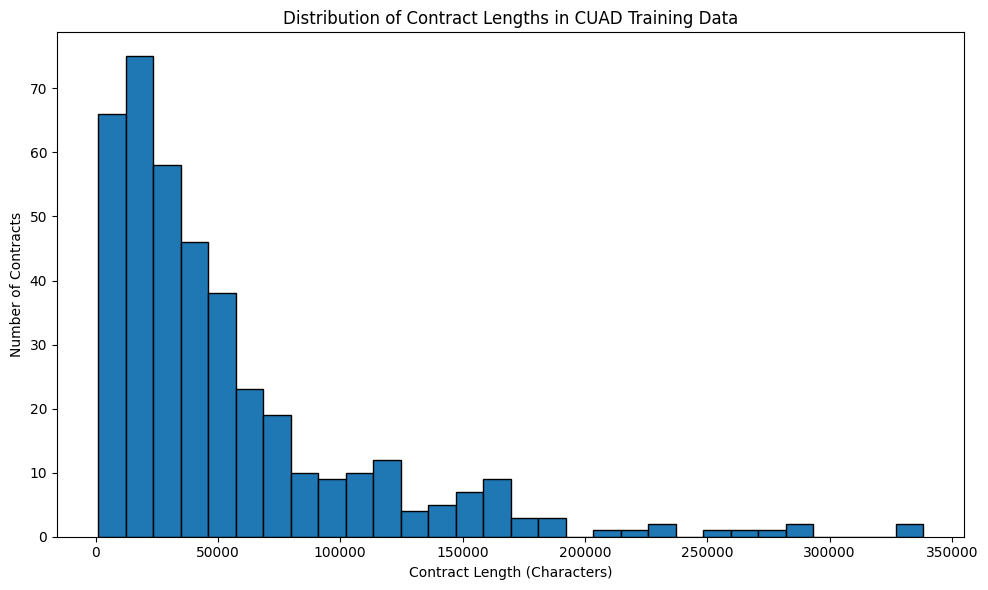

In [4]:
plt.figure(figsize=(10, 6))

plt.hist(contract_lengths, bins=30, edgecolor="black")

plt.xlabel("Contract Length (Characters)")
plt.ylabel("Number of Contracts")
plt.title("Distribution of Contract Lengths in CUAD Training Data")

plt.tight_layout()
plt.show()


### Observation

Most contracts are on the shorter end and a few are much longer, so the distribution is right skewed.Some contracts will need to be broken into smaller chunks before being used as input for the model.

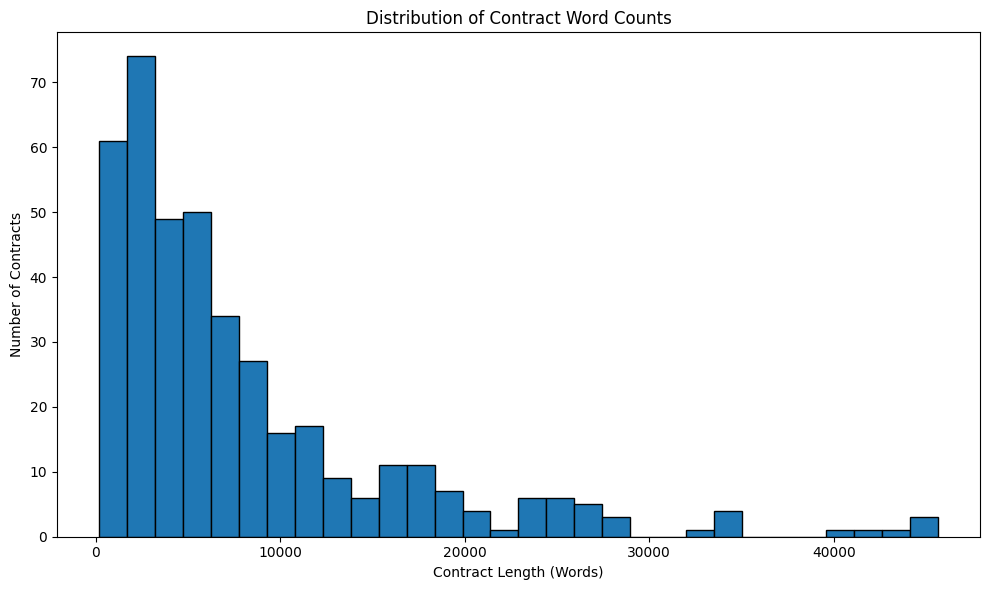

In [5]:
word_counts = []

for contract in contracts:
    text = ""

    for paragraph in contract["paragraphs"]:
        text += " " + paragraph["context"]

    word_counts.append(len(text.split()))

plt.figure(figsize=(10, 6))

plt.hist(word_counts, bins=30, edgecolor="black")

plt.xlabel("Contract Length (Words)")
plt.ylabel("Number of Contracts")
plt.title("Distribution of Contract Word Counts")

plt.tight_layout()
plt.show()

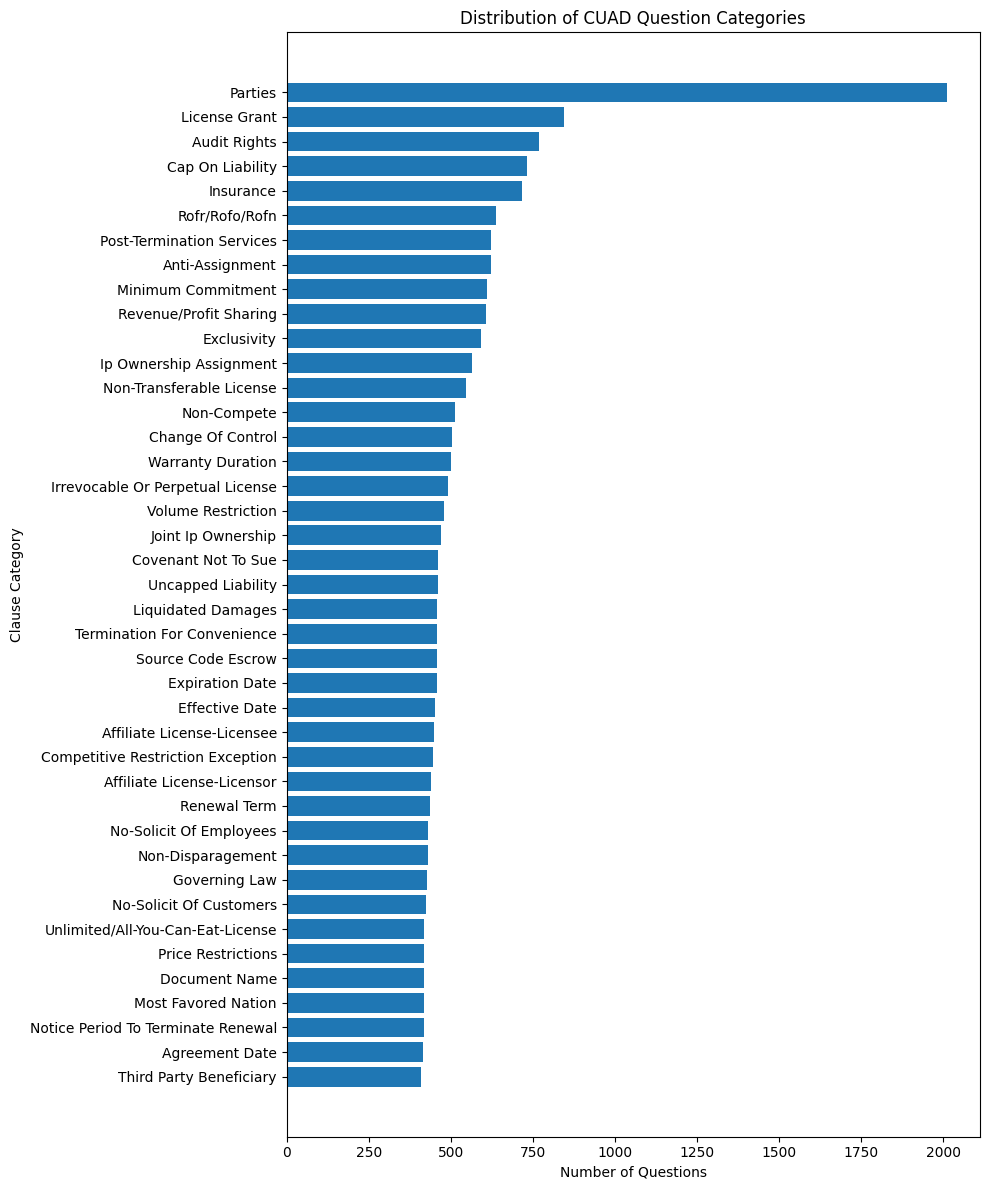

In [6]:
categories = {}

for contract in contracts:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:
            category = qa["id"].split("__")[1].rsplit("_", 1)[0]
            categories[category] = categories.get(category, 0) + 1

sorted_categories = sorted(
    categories.items(),
    key=lambda item: item[1]
)

category_names = [item[0] for item in sorted_categories]
category_counts = [item[1] for item in sorted_categories]

plt.figure(figsize=(10, 12))

plt.barh(category_names, category_counts)

plt.xlabel("Number of Questions")
plt.ylabel("Clause Category")
plt.title("Distribution of CUAD Question Categories")

plt.tight_layout()
plt.show()

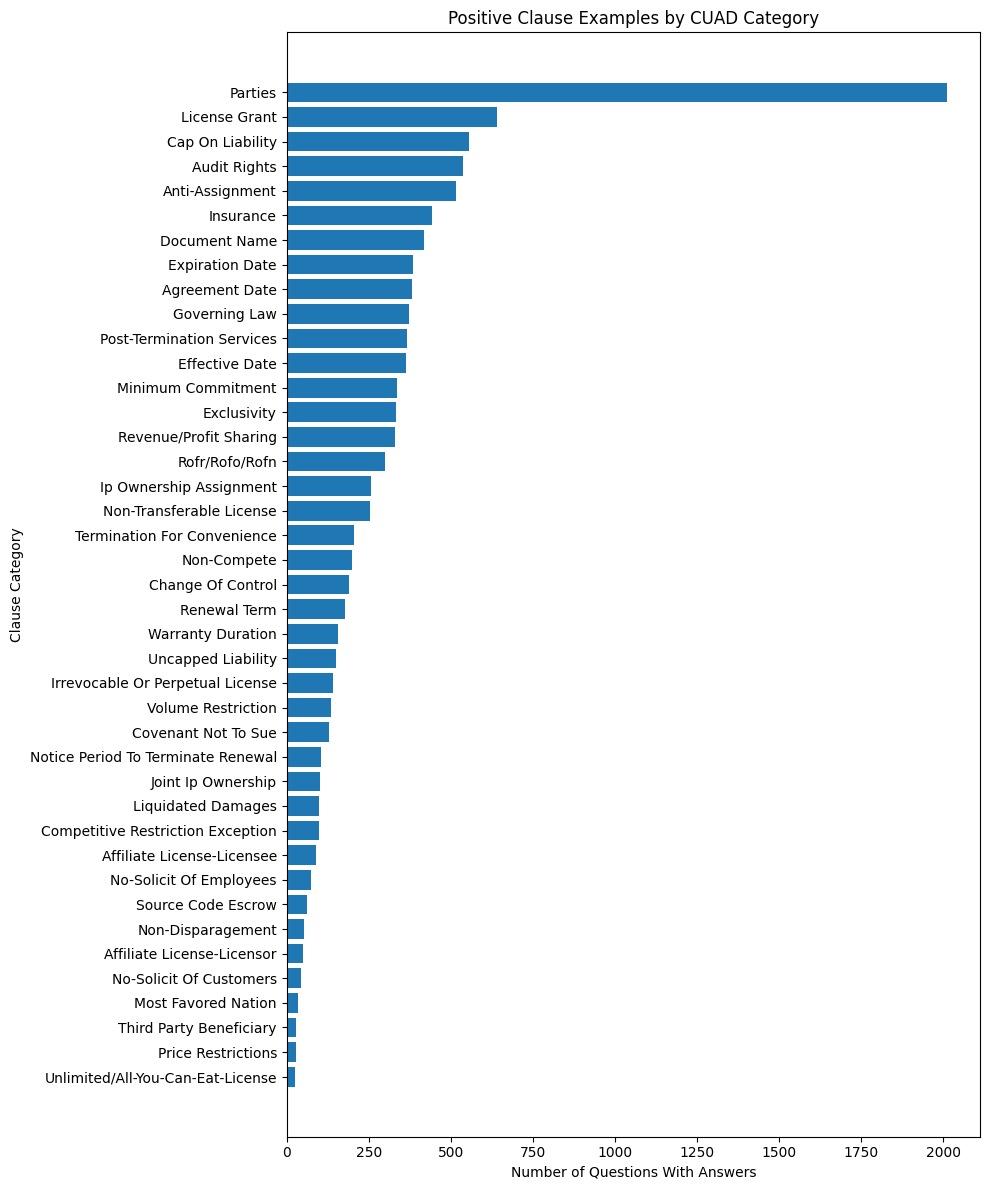

In [7]:
positive_categories = {}

for contract in contracts:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:
            category = qa["id"].split("__")[1].rsplit("_", 1)[0]

            if len(qa["answers"]) > 0:
                positive_categories[category] = (
                    positive_categories.get(category, 0) + 1
                )

# Include categories with zero positives, if any
for category in categories:
    positive_categories.setdefault(category, 0)

sorted_positive = sorted(
    positive_categories.items(),
    key=lambda item: item[1]
)

positive_names = [item[0] for item in sorted_positive]
positive_counts = [item[1] for item in sorted_positive]

plt.figure(figsize=(10, 12))

plt.barh(positive_names, positive_counts)

plt.xlabel("Number of Questions With Answers")
plt.ylabel("Clause Category")
plt.title("Positive Clause Examples by CUAD Category")

plt.tight_layout()
plt.show()

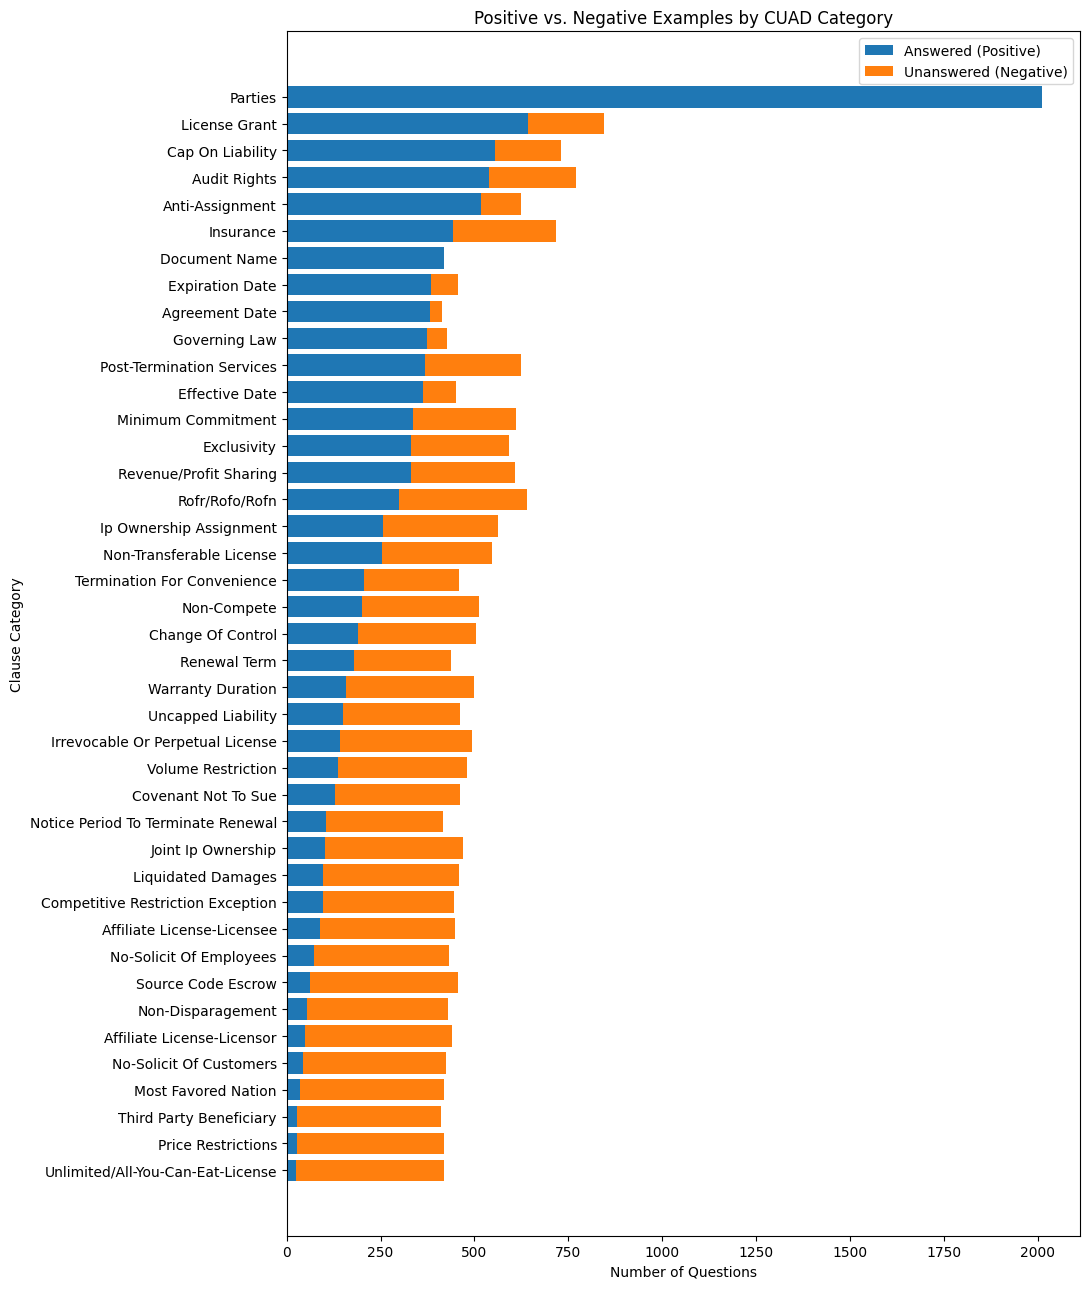

In [8]:
category_answer_counts = {}

for contract in contracts:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:
            category = qa["id"].split("__")[1].rsplit("_", 1)[0]

            if category not in category_answer_counts:
                category_answer_counts[category] = {
                    "positive": 0,
                    "negative": 0
                }

            if len(qa["answers"]) > 0:
                category_answer_counts[category]["positive"] += 1
            else:
                category_answer_counts[category]["negative"] += 1

# Sort categories by number of positive examples
sorted_items = sorted(
    category_answer_counts.items(),
    key=lambda item: item[1]["positive"]
)

category_names = [item[0] for item in sorted_items]
positive_counts = [item[1]["positive"] for item in sorted_items]
negative_counts = [item[1]["negative"] for item in sorted_items]

plt.figure(figsize=(11, 13))

plt.barh(
    category_names,
    positive_counts,
    label="Answered (Positive)"
)

plt.barh(
    category_names,
    negative_counts,
    left=positive_counts,
    label="Unanswered (Negative)"
)

plt.xlabel("Number of Questions")
plt.ylabel("Clause Category")
plt.title("Positive vs. Negative Examples by CUAD Category")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
print(f"{'Category':40} {'Positive':>10} {'Negative':>10} {'Positive %':>12}")
print("-" * 75)

category_rates = []

for category, counts in category_answer_counts.items():
    positive = counts["positive"]
    negative = counts["negative"]
    total = positive + negative
    positive_rate = (positive / total) * 100

    category_rates.append(
        (category, positive, negative, positive_rate)
    )

category_rates.sort(key=lambda x: x[3])

for category, positive, negative, rate in category_rates:
    print(
        f"{category:40} "
        f"{positive:10} "
        f"{negative:10} "
        f"{rate:11.1f}%"
    )

Category                                   Positive   Negative   Positive %
---------------------------------------------------------------------------
Unlimited/All-You-Can-Eat-License                26        394         6.2%
Price Restrictions                               27        393         6.4%
Third Party Beneficiary                          28        382         6.8%
Most Favored Nation                              35        383         8.4%
No-Solicit Of Customers                          43        381        10.1%
Affiliate License-Licensor                       49        391        11.1%
Non-Disparagement                                53        377        12.3%
Source Code Escrow                               61        396        13.3%
No-Solicit Of Employees                          73        359        16.9%
Affiliate License-Licensee                       88        361        19.6%
Liquidated Damages                               98        361        21.4%
Joint Ip Own